# Notebook 09 — From Pointwise to Global: Green's Theorem

Every notebook so far has treated curl and divergence as *pointwise*
quantities — a value computed independently at each grid cell. Green's
theorem says those pointwise values secretly encode something global:

$$\oint_C \mathbf{F}\cdot d\mathbf{l} = \iint_D (\nabla\times\mathbf{F})_z \, dA \qquad\qquad \oint_C \mathbf{F}\cdot\mathbf{n}\, ds = \iint_D (\nabla\cdot\mathbf{F})\, dA$$

Sum up the *local* rotation (curl) over every point inside a region $D$,
and you get the *global* circulation around its boundary $C$. Sum up the
local outflow (divergence), and you get the total flux crossing the
boundary. This notebook derives why that telescoping works, then checks
it numerically using the exact same grids and operators as every other
notebook here — no new machinery, just a new way of reading `curl_2d` and
`divergence_2d`'s output.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

from src import operators as ops


## 1. By hand — why local sums become a boundary integral

Take one small rectangle, corners $(x,y)$ to $(x+\Delta x, y+\Delta y)$,
and walk its boundary counter-clockwise. The circulation around it is

$$F_x(x,y)\Delta x + F_y(x+\Delta x, y)\Delta y - F_x(x, y+\Delta y)\Delta x - F_y(x,y)\Delta y$$

Group the like terms and recognize each bracket as a derivative times a
step:

$$\big[F_y(x+\Delta x,y) - F_y(x,y)\big]\Delta y - \big[F_x(x,y+\Delta y)-F_x(x,y)\big]\Delta x \approx \left(\frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y}\right)\Delta x\,\Delta y = (\nabla\times\mathbf{F})_z\,dA$$

That's exactly the pointwise formula from notebook 03 — circulation per
unit area, by construction.

**Now tile a whole region $D$ with many such rectangles** and add up every
rectangle's circulation. Two rectangles that share an edge traverse that
shared edge in *opposite* directions (each keeps its own boundary
counter-clockwise), so their contributions on that edge cancel exactly.
The only edges that *don't* get cancelled are the ones on the outer
boundary of $D$ — every interior edge is shared by two rectangles, but a
boundary edge belongs to just one. Sum every rectangle's circulation and
almost everything cancels, leaving only the single big loop around $D$:

$$\sum_{\text{cells}} (\nabla\times\mathbf{F})_z\,dA \;\longrightarrow\; \iint_D (\nabla\times\mathbf{F})_z\,dA \;=\; \oint_{\partial D} \mathbf{F}\cdot d\mathbf{l}$$

The same cancellation argument, applied to outward flux through each
rectangle's four sides instead of circulation around them, gives the
divergence/flux version. Nothing here is specific to a rectangle — any
region tiled finely enough works the same way — but a rectangle is what
lines up with a regular grid, so that's what the numerical check below
uses.

## 2. NumPy verification

Pick a field with **spatially varying** curl and divergence — a constant
curl would make this check too easy to trust. For $\mathbf{F}(x,y) =
(xy,\ x^2-y^2)$:

- $(\nabla\times\mathbf{F})_z = \partial_x(x^2-y^2) - \partial_y(xy) = 2x - x = x$
- $\nabla\cdot\mathbf{F} = \partial_x(xy) + \partial_y(x^2-y^2) = y - 2y = -y$

Both vary across the grid, so the two sides of each identity below have to
actually do the integration correctly to match — no shortcuts from
symmetry.

In [2]:
n = 400
x_vals = np.linspace(-3, 3, n)
y_vals = np.linspace(-3, 3, n)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

Fx = X * Y
Fy = X**2 - Y**2

curl = ops.curl_2d(Fx, Fy, dx, dy)
div = ops.divergence_2d(Fx, Fy, dx, dy)


In [3]:
# A rectangular region D = [x0, x1] x [y0, y1], strictly inside the grid.
# Deliberately off-center in both x and y: curl = x is odd in x and
# div = -y is odd in y, so a region symmetric about either axis would
# integrate one of them to a coincidental (and unilluminating) zero.
x0, x1 = -1.0, 2.0
y0, y1 = -1.8, 0.4

j0, j1 = np.searchsorted(x_vals, [x0, x1])
i0, i1 = np.searchsorted(y_vals, [y0, y1])

x_sub = x_vals[j0:j1 + 1]
y_sub = y_vals[i0:i1 + 1]

# --- Circulation form: boundary line integral of F.dl, counter-clockwise ---
circulation = (
    np.trapezoid(Fx[i0, j0:j1 + 1], x_sub)         # bottom edge, x increasing
    + np.trapezoid(Fy[i0:i1 + 1, j1], y_sub)        # right edge, y increasing
    - np.trapezoid(Fx[i1, j0:j1 + 1], x_sub)        # top edge, x increasing (subtract: we need x decreasing)
    - np.trapezoid(Fy[i0:i1 + 1, j0], y_sub)        # left edge, y increasing (subtract: we need y decreasing)
)

# --- Curl form: area integral of curl over D ---
curl_sub = curl[i0:i1 + 1, j0:j1 + 1]
area_integral_curl = np.trapezoid(np.trapezoid(curl_sub, x_sub, axis=1), y_sub)

print(f"circulation  ∮ F·dl        = {circulation:.5f}")
print(f"area integral ∬ curl dA    = {area_integral_curl:.5f}")
print(f"relative difference        = {abs(circulation - area_integral_curl) / abs(area_integral_curl):.2e}")


circulation  ∮ F·dl        = 3.34909
area integral ∬ curl dA    = 3.34909
relative difference        = 7.69e-15


In [4]:
# --- Flux form: boundary line integral of F.n ds, outward normal ---
flux = (
    np.trapezoid(Fx[i0:i1 + 1, j1], y_sub)          # right edge, outward normal = (+1, 0)
    - np.trapezoid(Fx[i0:i1 + 1, j0], y_sub)         # left edge, outward normal = (-1, 0)
    + np.trapezoid(Fy[i1, j0:j1 + 1], x_sub)         # top edge, outward normal = (0, +1)
    - np.trapezoid(Fy[i0, j0:j1 + 1], x_sub)         # bottom edge, outward normal = (0, -1)
)

# --- Divergence form: area integral of div over D ---
div_sub = div[i0:i1 + 1, j0:j1 + 1]
area_integral_div = np.trapezoid(np.trapezoid(div_sub, x_sub, axis=1), y_sub)

print(f"flux          ∮ F·n ds     = {flux:.5f}")
print(f"area integral ∬ div dA     = {area_integral_div:.5f}")
print(f"relative difference        = {abs(flux - area_integral_div) / abs(area_integral_div):.2e}")


flux          ∮ F·n ds     = 4.59875
area integral ∬ div dA     = 4.59875
relative difference        = 7.53e-15


## 3. Visualization

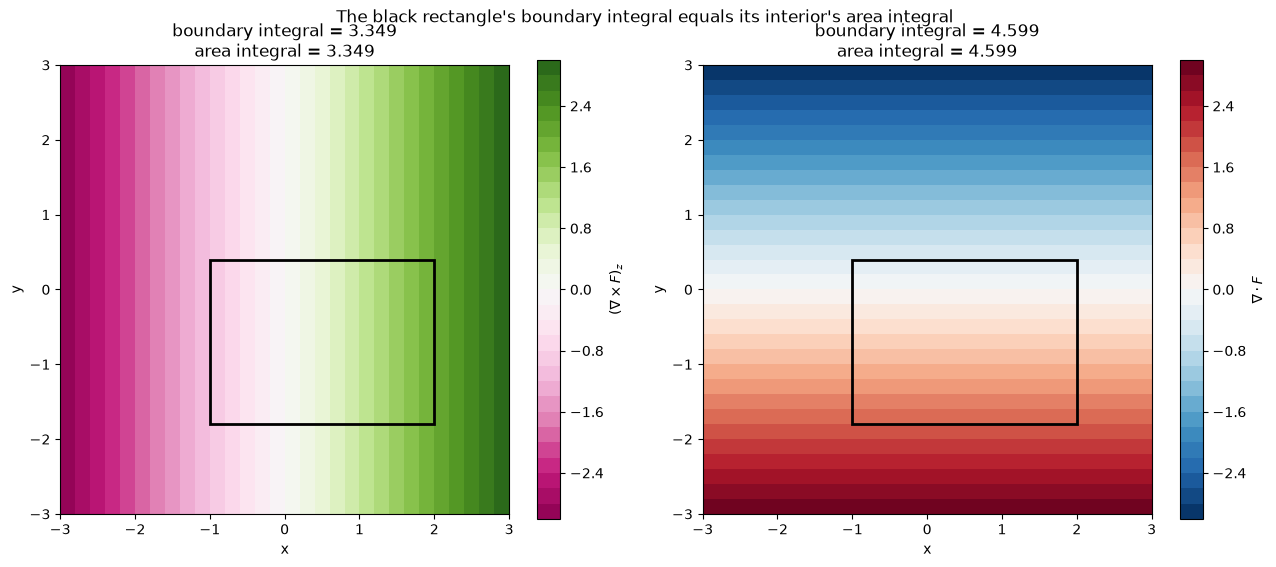

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

rect_xy = (x0, y0)
rect_w, rect_h = x1 - x0, y1 - y0

for ax, field, cmap, label, line_val, area_val in (
    (axes[0], curl, "PiYG", r"$(\nabla\times F)_z$", circulation, area_integral_curl),
    (axes[1], div, "RdBu_r", r"$\nabla\cdot F$", flux, area_integral_div),
):
    vmax = np.max(np.abs(field))
    c = ax.contourf(X, Y, field, levels=30, cmap=cmap, vmin=-vmax, vmax=vmax)
    fig.colorbar(c, ax=ax, label=label)
    ax.add_patch(patches.Rectangle(rect_xy, rect_w, rect_h, fill=False, edgecolor="black", linewidth=2))
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")

axes[0].set_title(f"boundary integral = {circulation:.3f}\narea integral = {area_integral_curl:.3f}")
axes[1].set_title(f"boundary integral = {flux:.3f}\narea integral = {area_integral_div:.3f}")
fig.suptitle("The black rectangle's boundary integral equals its interior's area integral")
fig.tight_layout()
plt.show()


**Reading this.** The black rectangle is the region $D$ from section 2.
Left panel: summing the green/magenta curl values inside the rectangle
gives the same number as walking its boundary and integrating $F$ along
the path. Right panel: same story for divergence and outward flux. The
two titles print both numbers, and they agree to about 14-15 significant
digits — machine precision, not just "close." That's a stronger match
than you'd expect from discretization error alone (compare to notebook
06, where finite-difference error was the *point*), and it's the same
phenomenon notebook 05 ran into: `curl_2d`/`divergence_2d` are built from
central-difference stencils, `np.trapezoid` is a fixed linear quadrature
rule, and composing two fixed linear operators on the same grid telescopes
*exactly* in floating-point arithmetic — the identity isn't approximately
true here, it's discretely true, with only round-off left over.

## 4. Exercise

Move the rectangle so it's no longer centered on the origin — e.g. `x0,
x1 = 0.5, 2.5` and `y0, y1 = -2.0, -0.5` — and confirm both identities
still hold. (They should: nothing in the derivation in section 1 assumed
anything about where the rectangle sits, only that it's tiled from little
squares.)

Then look ahead: `operators.py` also has `curl_3d` and `divergence_3d`.
Their integral-theorem counterparts are the full **Kelvin–Stokes theorem**
(circulation around a closed 3D curve equals the flux of curl through *any*
surface it bounds) and the **divergence theorem** (flux through a closed
3D surface equals the volume integral of divergence) — the same
telescoping argument from section 1, just with little cubes instead of
little squares. Verifying those numerically needs a way to integrate over
an arbitrary surface or a closed volume's boundary, which is a bigger lift
than slicing a rectangular region out of a grid; if you want to attempt it,
the simplest starting surface is another axis-aligned box, for exactly the
same reason a rectangle was the easy case here.


In [6]:
# Your answer here.
# x0, x1 = 0.5, 2.5
# y0, y1 = -2.0, -0.5
# ...
